In [1]:
import numpy as np
import tracemalloc
import time
# from nmrdfrommd.utilities import autocorrelation_function

from matplotlib import pyplot as plt

import sys
sys.path.append("../nmrdfrommd/")

In [2]:
from utilities import autocorrelation_function

In [3]:
# def test_autocorrelation_function_basic():
"""Test autocorrelation on a known periodic signal"""
np.random.seed(42)
t = np.linspace(0, 2*np.pi, 10000000)
omega = 5
signal = np.sin(omega * t) #  + 0.1 * np.random.randn(len(t))

Basic method
Duration: 2.12 s
Current memory: 80.0 MB
Peak memory: 2039.12 MB


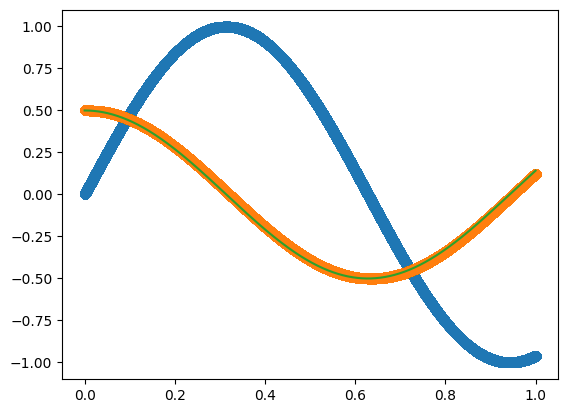

In [ ]:
# Compute autocorrelation
ti = time.time()
tracemalloc.start()

acf = autocorrelation_function(signal)
tf = time.time()

current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

print("Basic method")
print("Duration:", round(tf - ti, 2), "s")
print("Current memory:", round(current / 1e6, 2), "MB")
print("Peak memory:", round(peak / 1e6, 2), "MB")

solution = 0.5 * np.cos(omega * t) #  + 0.1 * np.random.randn(len(t))

plt.plot(t[t<1], signal[t<1], "o")
plt.plot(t[t<1], acf[t<1], "o")
plt.plot(t[t<1], solution[t<1], "-")
# plt.savefig("basic.png")
plt.show()


Wiener method
Duration: 2.01 s
Current memory: 80.0 MB
Peak memory: 1770.68 MB


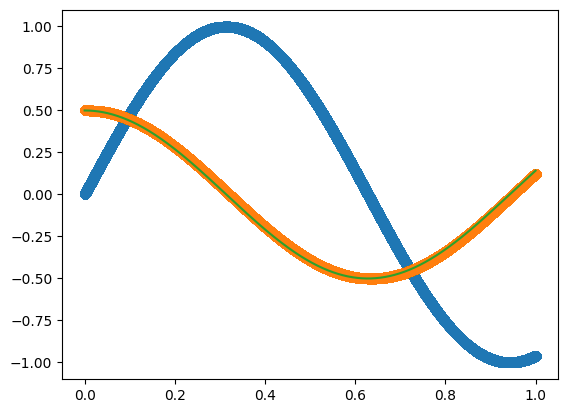

In [ ]:
# Compute autocorrelation
ti = time.time()
tracemalloc.start()

acf = autocorrelation_function(signal, use_wiener_khinchin=True)
tf = time.time()

current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

print("Wiener method")
print("Duration:", round(tf - ti, 2), "s")
print("Current memory:", round(current / 1e6, 2), "MB")
print("Peak memory:", round(peak / 1e6, 2), "MB")

solution = 0.5 * np.cos(omega * t) #  + 0.1 * np.random.randn(len(t))

plt.plot(t[t<1], signal[t<1], "o")
plt.plot(t[t<1], acf[t<1], "o")
plt.plot(t[t<1], solution[t<1], "-")
# plt.savefig("wiener.png")
plt.show()


In [6]:
# Compute autocorrelation
ti = time.time()
tracemalloc.start()

acf = autocorrelation_function(signal, use_gpu=True)
tf = time.time()

current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

print("Wiener method")
print("Duration:", round(tf - ti, 2), "s")
print("Current memory:", round(current / 1e6, 2), "MB")
print("Peak memory:", round(peak / 1e6, 2), "MB")

solution = 0.5 * np.cos(omega * t) #  + 0.1 * np.random.randn(len(t))

plt.plot(t[t<1], signal[t<1], "o")
plt.plot(t[t<1], acf[t<1], "o")
plt.plot(t[t<1], solution[t<1], "-")
plt.savefig("gpu.png")
plt.show()


ImportError: CuPy is not installed.